In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.statespace.structural import UnobservedComponents

In [3]:
columns = ['engine_id', 'cycle',
           'setting_1', 'setting_2', 'setting_3',
           'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
           'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8',
           'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
           'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
           'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
           'sensor_21']

df = pd.read_csv('../data/train_FD001.txt',
                 sep='\s+',
                 header=None,
                 names=columns,
                 engine='python')

print(df.shape)
print(df.isnull().sum())

(20631, 26)
engine_id    0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64


In [4]:
print(df.dtypes)

engine_id      int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
sensor_1     float64
sensor_2     float64
sensor_3     float64
sensor_4     float64
sensor_5     float64
sensor_6     float64
sensor_7     float64
sensor_8     float64
sensor_9     float64
sensor_10    float64
sensor_11    float64
sensor_12    float64
sensor_13    float64
sensor_14    float64
sensor_15    float64
sensor_16    float64
sensor_17      int64
sensor_18      int64
sensor_19    float64
sensor_20    float64
sensor_21    float64
dtype: object


In [5]:
sensor_cols = [f'sensor_{i}' for i in range(1,22)]
variance = df[sensor_cols].var()
print("sensor_variances:")
print(variance.sort_values())

sensor_variances:
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


In [6]:
setting_cols = ['setting_1', 'setting_2', 'setting_3']
print(df[setting_cols].var())

setting_1    4.784340e-06
setting_2    8.588541e-08
setting_3    0.000000e+00
dtype: float64


In [7]:
drop_cols = ['setting_1', 'setting_2', 'setting_3',
             'sensor_1', 'sensor_5', 'sensor_10',
             'sensor_16', 'sensor_18', 'sensor_19']

df = df.drop(drop_cols, axis=1)

print(df.shape)
print(df.columns.tolist())

(20631, 17)
['engine_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [8]:
# find max cycle for each engine
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# merge back to main dataframe
df = df.merge(max_cycles, on='engine_id')

# calculate RUL
df['RUL'] = df['max_cycle'] - df['cycle']

# drop max_cycle column (no longer needed)
df = df.drop('max_cycle', axis=1)

print(df.shape)
print(df[['engine_id', 'cycle', 'RUL']].head(100))
print(f"\nMax RUL: {df['RUL'].max()}")
print(f"Min RUL: {df['RUL'].min()}")

(20631, 18)
    engine_id  cycle  RUL
0           1      1  191
1           1      2  190
2           1      3  189
3           1      4  188
4           1      5  187
..        ...    ...  ...
95          1     96   96
96          1     97   95
97          1     98   94
98          1     99   93
99          1    100   92

[100 rows x 3 columns]

Max RUL: 361
Min RUL: 0


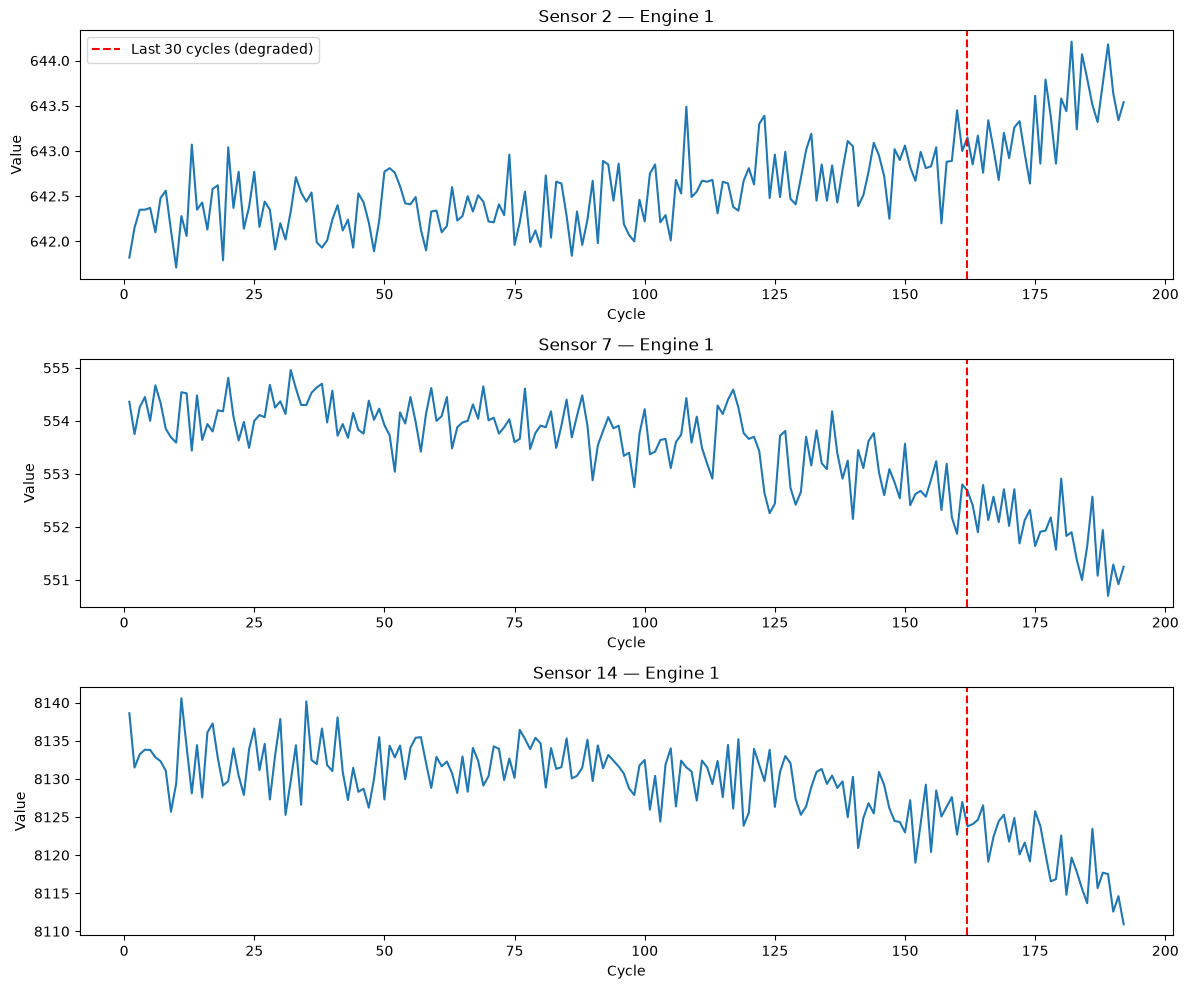

In [9]:
engine_1 = df[df['engine_id'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(engine_1['cycle'], engine_1['sensor_2'])
axes[0].set_title('Sensor 2 — Engine 1')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Value')
axes[0].axvline(x=engine_1['cycle'].max() - 30,
                color='r', linestyle='--',
                label='Last 30 cycles (degraded)')
axes[0].legend()

axes[1].plot(engine_1['cycle'], engine_1['sensor_7'])
axes[1].set_title('Sensor 7 — Engine 1')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Value')
axes[1].axvline(x=engine_1['cycle'].max() - 30,
                color='r', linestyle='--')

axes[2].plot(engine_1['cycle'], engine_1['sensor_14'])
axes[2].set_title('Sensor 14 — Engine 1')
axes[2].set_xlabel('Cycle')
axes[2].set_ylabel('Value')
axes[2].axvline(x=engine_1['cycle'].max() - 30,
                color='r', linestyle='--')

plt.tight_layout()
plt.savefig('sensor_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
sensor_cols = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6',
               'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
               'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
               'sensor_17', 'sensor_20', 'sensor_21']

correlations = df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')
print("Sensor correlations with RUL:")
print(correlations.sort_values())

Sensor correlations with RUL:
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
Name: RUL, dtype: float64


In [11]:
from sklearn.preprocessing import MinMaxScaler

# drop weak sensor
df = df.drop('sensor_6', axis=1)

# define final sensor columns
final_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
                 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
                 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
                 'sensor_20', 'sensor_21']

# normalise sensors to 0-1 range
scaler = MinMaxScaler()
df[final_sensors] = scaler.fit_transform(df[final_sensors])

print(df[final_sensors].describe().round(3))

        sensor_2   sensor_3   sensor_4   sensor_7   sensor_8   sensor_9  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.443      0.425      0.450      0.566      0.298      0.195   
std        0.151      0.134      0.152      0.143      0.108      0.099   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%        0.336      0.332      0.339      0.477      0.227      0.141   
50%        0.431      0.416      0.435      0.578      0.288      0.175   
75%        0.539      0.509      0.545      0.670      0.364      0.214   
max        1.000      1.000      1.000      1.000      1.000      1.000   

       sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.411      0.581      0.318      0.226      0.451      0.434   
std        0.159      0.157      0.106      0.098      0.144      0.129   
min        0.000      0.

In [12]:
# separate healthy and degraded data
healthy = df[df['RUL'] > 30]
degraded = df[df['RUL'] <= 30]

print(f"Healthy cycles:   {len(healthy)} ({len(healthy)/len(df)*100:.1f}%)")
print(f"Degraded cycles:  {len(degraded)} ({len(degraded)/len(df)*100:.1f}%)")
print(f"\nHealthy engines stats:")
print(healthy[final_sensors].describe().round(3).loc[['mean', 'std']])

Healthy cycles:   17531 (85.0%)
Degraded cycles:  3100 (15.0%)

Healthy engines stats:
      sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  sensor_9  sensor_11  \
mean     0.406     0.393     0.409     0.604     0.273     0.178      0.367   
std      0.125     0.112     0.118     0.113     0.089     0.059      0.122   

      sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  sensor_20  \
mean      0.623      0.294      0.212      0.414      0.403      0.560   
std       0.123      0.087      0.060      0.116      0.106      0.114   

      sensor_21  
mean      0.584  
std       0.121  


In [13]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

# use engine 1 as example
engine_1_healthy = df[(df['engine_id'] == 1) &
                      (df['RUL'] > 30)]['sensor_11']

# fit local level SSM on healthy data
ssm_model = UnobservedComponents(
    engine_1_healthy,
    level='local level'
)

ssm_result = ssm_model.fit(disp=False)
print(ssm_result.summary())

                        Unobserved Components Results                         
Dep. Variable:              sensor_11   No. Observations:                  161
Model:                    local level   Log Likelihood                 194.978
Date:                Wed, 29 Jul 2026   AIC                           -385.955
Time:                        15:08:27   BIC                           -379.805
Sample:                             0   HQIC                          -383.458
                                - 161                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     0.0044      0.001      8.261      0.000       0.003       0.005
sigma2.level      8.261e-05   5.59e-05      1.478      0.139    -2.7e-05       0.000
Ljung-Box (L1) (Q):         

Actual shape:    (192,)
Predicted shape: (192,)


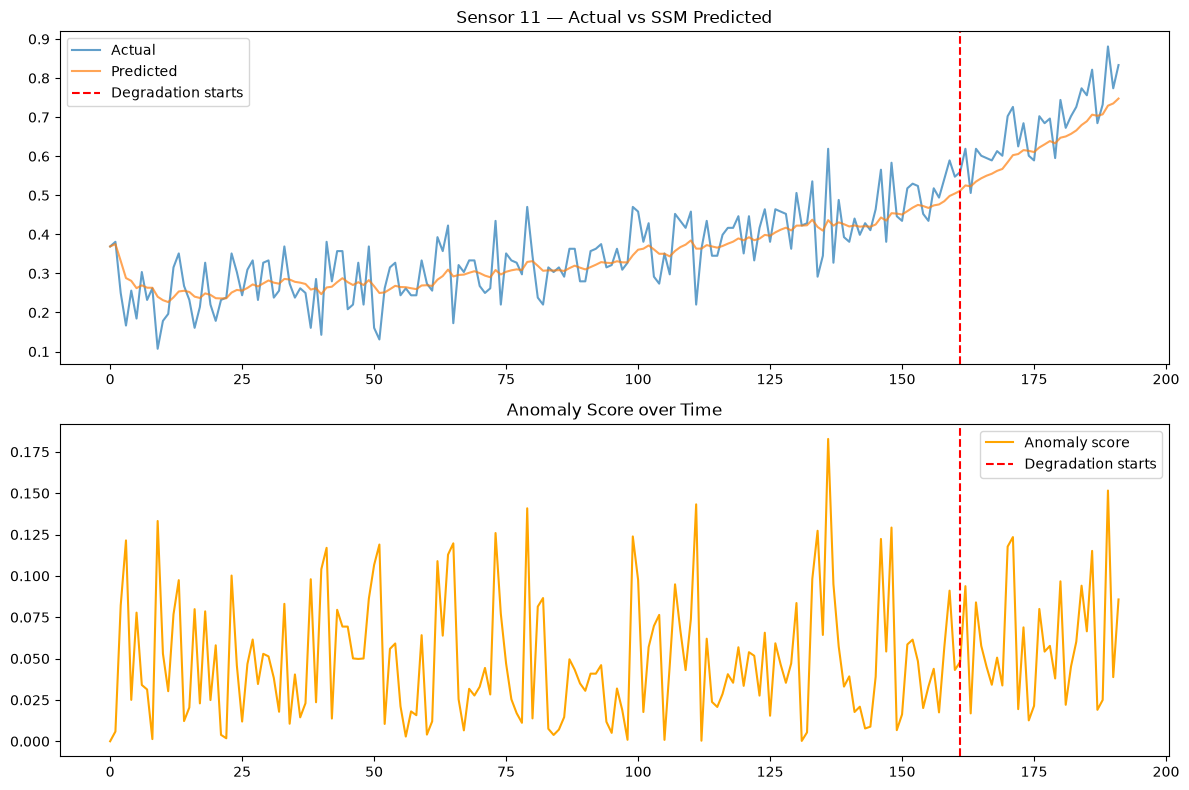

Mean anomaly score (healthy):   0.0492
Mean anomaly score (degraded):  0.0605
Ratio degraded/healthy:         1.23x


In [14]:
# get all cycles for engine 1
engine_1_all = df[df['engine_id'] == 1]['sensor_11']

# apply fitted model to all cycles
prediction = ssm_result.apply(engine_1_all)
predicted_values = prediction.predicted_state[0]


predicted_values = predicted_values[1:]

# get actual values
actual_values = engine_1_all.values

print(f"Actual shape:    {actual_values.shape}")
print(f"Predicted shape: {predicted_values.shape}")

# calculate anomaly score
anomaly_scores = np.abs(actual_values - predicted_values)
# plot results
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(actual_values, label='Actual', alpha=0.7)
axes[0].plot(predicted_values, label='Predicted', alpha=0.7)
axes[0].axvline(x=161, color='r', linestyle='--',
                label='Degradation starts')
axes[0].set_title('Sensor 11 — Actual vs SSM Predicted')
axes[0].legend()

axes[1].plot(anomaly_scores, color='orange', label='Anomaly score')
axes[1].axvline(x=161, color='r', linestyle='--',
                label='Degradation starts')
axes[1].set_title('Anomaly Score over Time')
axes[1].legend()

plt.tight_layout()
plt.savefig('ssm_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# text summary
print(f"Mean anomaly score (healthy):   "
      f"{anomaly_scores[:161].mean():.4f}")
print(f"Mean anomaly score (degraded):  "
      f"{anomaly_scores[161:].mean():.4f}")
print(f"Ratio degraded/healthy:         "
      f"{anomaly_scores[161:].mean()/anomaly_scores[:161].mean():.2f}x")

Anomaly threshold: 0.2075


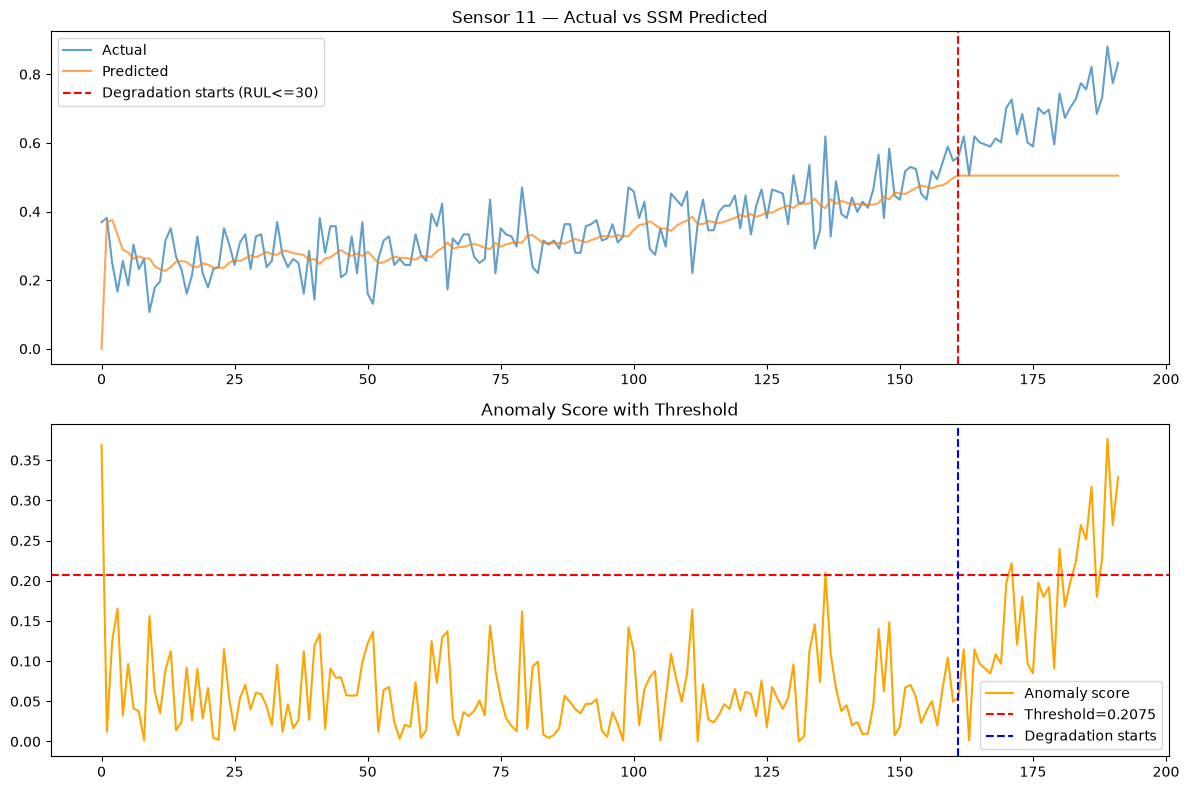


Mean score healthy:  0.0592
Mean score degraded: 0.1733
Ratio:               2.93x

Anomalies detected in healthy region: 2 / 161
Anomalies detected in degraded region: 10 / 31


In [15]:
# Step 1 - fit on healthy data only (already done)
# engine_1_healthy → ssm_result

# Step 2 - get in-sample fitted values on healthy data
fitted = ssm_result.fittedvalues
healthy_errors = np.abs(
    engine_1_healthy.values - fitted.values
)

# Step 3 - set threshold as mean + 3 standard deviations
threshold = healthy_errors.mean() + 3 * healthy_errors.std()
print(f"Anomaly threshold: {threshold:.4f}")

# Step 4 - get predictions on full engine 1 data
forecast = ssm_result.get_prediction(
    start=0,
    end=len(engine_1_all) - 1,
    exog=engine_1_all
)
predicted = forecast.predicted_mean

# Step 5 - compute anomaly scores
anomaly_scores = np.abs(engine_1_all.values - predicted.values)

# Step 6 - flag anomalies
is_anomaly = anomaly_scores > threshold

# Step 7 - plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(engine_1_all.values, label='Actual', alpha=0.7)
axes[0].plot(predicted.values, label='Predicted', alpha=0.7)
axes[0].axvline(x=161, color='r', linestyle='--',
                label='Degradation starts (RUL<=30)')
axes[0].set_title('Sensor 11 — Actual vs SSM Predicted')
axes[0].legend()

axes[1].plot(anomaly_scores, color='orange',
             label='Anomaly score')
axes[1].axhline(y=threshold, color='r', linestyle='--',
                label=f'Threshold={threshold:.4f}')
axes[1].axvline(x=161, color='b', linestyle='--',
                label='Degradation starts')
axes[1].set_title('Anomaly Score with Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('ssm_anomaly_detection.png', dpi=150,
            bbox_inches='tight')
plt.show()

# text summary
print(f"\nMean score healthy:  {anomaly_scores[:161].mean():.4f}")
print(f"Mean score degraded: {anomaly_scores[161:].mean():.4f}")
print(f"Ratio:               "
      f"{anomaly_scores[161:].mean()/anomaly_scores[:161].mean():.2f}x")
print(f"\nAnomalies detected in healthy region: "
      f"{is_anomaly[:161].sum()} / 161")
print(f"Anomalies detected in degraded region: "
      f"{is_anomaly[161:].sum()} / 31")

In [16]:
from statsmodels.tsa.statespace.structural import UnobservedComponents
import warnings
warnings.filterwarnings('ignore')

# correlation weights from earlier analysis
corr_weights = {
    'sensor_2': 0.606, 'sensor_3': 0.585, 'sensor_4': 0.679,
    'sensor_7': 0.657, 'sensor_8': 0.564, 'sensor_9': 0.390,
    'sensor_11': 0.696, 'sensor_12': 0.672, 'sensor_13': 0.563,
    'sensor_14': 0.307, 'sensor_15': 0.643, 'sensor_17': 0.606,
    'sensor_20': 0.629, 'sensor_21': 0.636
}

# train one SSM per sensor on ALL healthy data
ssm_models = {}
thresholds = {}
healthy_data = df[df['RUL'] > 30]

print("Training SSM for each sensor...")
for sensor in final_sensors:
    # use mean healthy values per cycle position
    sensor_healthy = healthy_data[sensor]

    model = UnobservedComponents(
        sensor_healthy,
        level='local level'
    )
    result = model.fit(disp=False)

    # compute threshold from healthy errors
    fitted = result.fittedvalues
    errors = np.abs(sensor_healthy.values - fitted.values)
    threshold = errors.mean() + 3 * errors.std()

    ssm_models[sensor] = result
    thresholds[sensor] = threshold

    print(f"  {sensor}: threshold={threshold:.4f}")

print("\nAll SSM models trained!")

Training SSM for each sensor...
  sensor_2: threshold=0.2636
  sensor_3: threshold=0.2484
  sensor_4: threshold=0.2070
  sensor_7: threshold=0.2003
  sensor_8: threshold=0.1397
  sensor_9: threshold=0.0714
  sensor_11: threshold=0.1921
  sensor_12: threshold=0.2016
  sensor_13: threshold=0.1361
  sensor_14: threshold=0.0646
  sensor_15: threshold=0.2272
  sensor_17: threshold=0.2276
  sensor_20: threshold=0.2301
  sensor_21: threshold=0.2432

All SSM models trained!


In [17]:
def compute_anomaly_score(engine_data, ssm_models,
                          thresholds, corr_weights):
    scores = {}
    individual_anomalies = {}

    for sensor in final_sensors:
        sensor_data = engine_data[sensor]

        # get predictions from fitted model
        fitted = ssm_models[sensor].fittedvalues
        fitted_mean = fitted.mean()
        fitted_std = fitted.std()

        # compute errors using threshold comparison
        errors = np.abs(
            sensor_data.values -
            np.full(len(sensor_data), fitted_mean)
        )

        # weight by correlation strength
        weight = corr_weights[sensor]
        scores[sensor] = errors * weight
        individual_anomalies[sensor] = (
            errors > thresholds[sensor]
        )

    # combine weighted scores
    weighted_score = np.mean(
        list(scores.values()), axis=0
    )

    return weighted_score, individual_anomalies


# test on engine 1
engine_1_data = df[df['engine_id'] == 1]
weighted_scores, individual = compute_anomaly_score(
    engine_1_data, ssm_models, thresholds, corr_weights
)

# find overall threshold
overall_threshold = np.percentile(
    weighted_scores[:161], 95
)
is_anomaly = weighted_scores > overall_threshold

print(f"Overall threshold (95th percentile): "
      f"{overall_threshold:.4f}")
print(f"\nAnomalies in healthy region: "
      f"{is_anomaly[:161].sum()} / 161")
print(f"Anomalies in degraded region: "
      f"{is_anomaly[161:].sum()} / 31")
print(f"\nDetection rate: "
      f"{is_anomaly[161:].sum()/31*100:.1f}%")
print(f"False alarm rate: "
      f"{is_anomaly[:161].sum()/161*100:.1f}%")

Overall threshold (95th percentile): 0.0658

Anomalies in healthy region: 8 / 161
Anomalies in degraded region: 31 / 31

Detection rate: 100.0%
False alarm rate: 5.0%


In [18]:
all_results = []

for engine_id in df['engine_id'].unique():
    engine_data = df[df['engine_id'] == engine_id]

    # find where degradation starts for this engine
    degradation_start = len(
        engine_data[engine_data['RUL'] > 30]
    )
    total_cycles = len(engine_data)
    degraded_cycles = total_cycles - degradation_start

    # compute weighted anomaly scores
    weighted_scores, _ = compute_anomaly_score(
        engine_data, ssm_models,
        thresholds, corr_weights
    )

    # apply threshold
    is_anomaly = weighted_scores > overall_threshold

    # calculate metrics
    if degradation_start > 0:
        false_alarms = is_anomaly[:degradation_start].sum()
        false_alarm_rate = (
            false_alarms / degradation_start * 100
        )
    else:
        false_alarms = 0
        false_alarm_rate = 0

    if degraded_cycles > 0:
        detections = is_anomaly[degradation_start:].sum()
        detection_rate = detections / degraded_cycles * 100
    else:
        detections = 0
        detection_rate = 0

    all_results.append({
        'engine_id': engine_id,
        'total_cycles': total_cycles,
        'healthy_cycles': degradation_start,
        'degraded_cycles': degraded_cycles,
        'false_alarms': false_alarms,
        'false_alarm_rate': false_alarm_rate,
        'detections': detections,
        'detection_rate': detection_rate
    })

results_df = pd.DataFrame(all_results)

print("=" * 50)
print("ANOMALY DETECTION — ALL 100 ENGINES")
print("=" * 50)
print(f"\nMean detection rate:   "
      f"{results_df['detection_rate'].mean():.2f}%")
print(f"Std detection rate:    "
      f"{results_df['detection_rate'].std():.2f}%")
print(f"Min detection rate:    "
      f"{results_df['detection_rate'].min():.2f}%")
print(f"\nMean false alarm rate: "
      f"{results_df['false_alarm_rate'].mean():.2f}%")
print(f"Std false alarm rate:  "
      f"{results_df['false_alarm_rate'].std():.2f}%")
print(f"Max false alarm rate:  "
      f"{results_df['false_alarm_rate'].max():.2f}%")
print(f"\nEngines with 100% detection: "
      f"{(results_df['detection_rate']==100).sum()} / 100")
print(f"Engines with >80% detection: "
      f"{(results_df['detection_rate']>=80).sum()} / 100")
print(f"Engines with <50% detection: "
      f"{(results_df['detection_rate']<50).sum()} / 100")

ANOMALY DETECTION — ALL 100 ENGINES

Mean detection rate:   97.97%
Std detection rate:    4.17%
Min detection rate:    80.65%

Mean false alarm rate: 21.30%
Std false alarm rate:  14.08%
Max false alarm rate:  50.89%

Engines with 100% detection: 76 / 100
Engines with >80% detection: 100 / 100
Engines with <50% detection: 0 / 100


In [19]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# save all 14 SSM models
joblib.dump(ssm_models, '../models/ssm_models.pkl')

# save thresholds
joblib.dump(thresholds, '../models/thresholds.pkl')

# save overall threshold
joblib.dump(overall_threshold,
            '../models/overall_threshold.pkl')

# save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# save correlation weights
joblib.dump(corr_weights, '../models/corr_weights.pkl')

# save final sensor list
joblib.dump(final_sensors, '../models/feature_columns.pkl')

print("All models and artifacts saved!")
print(f"Files saved:")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f} → {size/1024:.1f} KB")

All models and artifacts saved!
Files saved:
  corr_weights.pkl → 0.3 KB
  feature_columns.pkl → 0.2 KB
  overall_threshold.pkl → 0.1 KB
  scaler.pkl → 1.6 KB
  ssm_models.pkl → 212591.6 KB
  thresholds.pkl → 0.5 KB


In [20]:
import json

row = df[df['engine_id'] == 1].iloc[0]
sensor_data = {
    'engine_id': 1,
    'cycle': int(row['cycle']),
    'sensor_2': float(row['sensor_2']),
    'sensor_3': float(row['sensor_3']),
    'sensor_4': float(row['sensor_4']),
    'sensor_7': float(row['sensor_7']),
    'sensor_8': float(row['sensor_8']),
    'sensor_9': float(row['sensor_9']),
    'sensor_11': float(row['sensor_11']),
    'sensor_12': float(row['sensor_12']),
    'sensor_13': float(row['sensor_13']),
    'sensor_14': float(row['sensor_14']),
    'sensor_15': float(row['sensor_15']),
    'sensor_17': float(row['sensor_17']),
    'sensor_20': float(row['sensor_20']),
    'sensor_21': float(row['sensor_21'])
}
print(json.dumps(sensor_data, indent=2))

{
  "engine_id": 1,
  "cycle": 1,
  "sensor_2": 0.18373493975903443,
  "sensor_3": 0.4068018312622641,
  "sensor_4": 0.30975692099932317,
  "sensor_7": 0.72624798711756,
  "sensor_8": 0.24242424242402194,
  "sensor_9": 0.10975500314098952,
  "sensor_11": 0.3690476190476204,
  "sensor_12": 0.6332622601279212,
  "sensor_13": 0.20588235294098922,
  "sensor_14": 0.1996078026628112,
  "sensor_15": 0.36398614851866284,
  "sensor_17": 0.3333333333333357,
  "sensor_20": 0.7131782945736447,
  "sensor_21": 0.7246616956641816
}


In [21]:
row = df[df['engine_id'] == 1].iloc[0]
print("sensor_2 value:", row['sensor_2'])
print("Is this scaled (should be 0-1)?",
      0 <= row['sensor_2'] <= 1)

sensor_2 value: 0.18373493975903443
Is this scaled (should be 0-1)? True


In [22]:
degraded_row = df[
    (df['engine_id'] == 1) &
    (df['RUL'] <= 5)
].iloc[0]

sensor_data_degraded = {
    'engine_id': 1,
    'cycle': int(degraded_row['cycle']),
    'sensor_2': float(degraded_row['sensor_2']),
    'sensor_3': float(degraded_row['sensor_3']),
    'sensor_4': float(degraded_row['sensor_4']),
    'sensor_7': float(degraded_row['sensor_7']),
    'sensor_8': float(degraded_row['sensor_8']),
    'sensor_9': float(degraded_row['sensor_9']),
    'sensor_11': float(degraded_row['sensor_11']),
    'sensor_12': float(degraded_row['sensor_12']),
    'sensor_13': float(degraded_row['sensor_13']),
    'sensor_14': float(degraded_row['sensor_14']),
    'sensor_15': float(degraded_row['sensor_15']),
    'sensor_17': float(degraded_row['sensor_17']),
    'sensor_20': float(degraded_row['sensor_20']),
    'sensor_21': float(degraded_row['sensor_21'])
}
print(json.dumps(sensor_data_degraded, indent=2))
print(f"RUL: {int(degraded_row['RUL'])}")

{
  "engine_id": 1,
  "cycle": 187,
  "sensor_2": 0.6355421686747036,
  "sensor_3": 0.45912361020274517,
  "sensor_4": 0.7599594868332211,
  "sensor_7": 0.19806763285023976,
  "sensor_8": 0.5909090909090082,
  "sensor_9": 0.07170420892039431,
  "sensor_11": 0.8214285714285694,
  "sensor_12": 0.17910447761192927,
  "sensor_13": 0.5882352941175668,
  "sensor_14": 0.08117452781505108,
  "sensor_15": 0.7575990765679137,
  "sensor_17": 0.6666666666666714,
  "sensor_20": 0.21705426356589186,
  "sensor_21": 0.2595967964650647
}
RUL: 5


In [23]:
# load test data
df_test = pd.read_csv('../data/test_FD001.txt',
                      sep='\s+',
                      header=None,
                      names=columns,
                      engine='python')

# load RUL ground truth
rul_test = pd.read_csv('../data/RUL_FD001.txt',
                       sep='\s+',
                       header=None,
                       names=['RUL'],
                       engine='python')

print(f"Test engines: {df_test['engine_id'].nunique()}")
print(f"Test rows: {len(df_test)}")
print(f"RUL values: {len(rul_test)}")
print(f"\nFirst 5 RUL values:")
print(rul_test.head())

Test engines: 100
Test rows: 13096
RUL values: 100

First 5 RUL values:
   RUL
0  112
1   98
2   69
3   82
4   91


In [24]:
# apply same preprocessing as training data
df_test = df_test.drop(drop_cols, axis=1)
df_test = df_test.drop('sensor_6', axis=1)

# add RUL ground truth to each engine
# RUL at last cycle = rul_test value
# RUL at earlier cycles = rul_test + cycles remaining
max_cycles_test = df_test.groupby(
    'engine_id')['cycle'].max().reset_index()
max_cycles_test.columns = ['engine_id', 'max_cycle']
df_test = df_test.merge(max_cycles_test, on='engine_id')

# add true RUL column
rul_test['engine_id'] = range(1, 101)
df_test = df_test.merge(rul_test, on='engine_id')
df_test['RUL'] = (
    df_test['max_cycle'] - df_test['cycle'] + df_test['RUL']
)
df_test = df_test.drop('max_cycle', axis=1)

# normalise using SAME scaler from training
df_test[final_sensors] = scaler.transform(
    df_test[final_sensors]
)

print(f"Test data shape: {df_test.shape}")
print(f"\nRUL distribution in test data:")
print(df_test['RUL'].describe().round(2))

Test data shape: (13096, 17)

RUL distribution in test data:
count    13096.00
mean       141.24
std         58.98
min          7.00
25%        102.00
50%        140.00
75%        179.00
max        340.00
Name: RUL, dtype: float64


In [25]:
test_results = []

for engine_id in df_test['engine_id'].unique():
    engine_data = df_test[df_test['engine_id'] == engine_id]
    final_rul = rul_test[
        rul_test['engine_id'] == engine_id
    ]['RUL'].values[0]

    weighted_scores, _ = compute_anomaly_score(
        engine_data, ssm_models, thresholds, corr_weights
    )

    is_anomaly = weighted_scores > overall_threshold
    anomaly_rate = is_anomaly.mean() * 100

    test_results.append({
        'engine_id': engine_id,
        'final_rul': final_rul,
        'total_cycles': len(engine_data),
        'anomaly_rate': anomaly_rate,
        'high_risk': final_rul < 50
    })

test_results_df = pd.DataFrame(test_results)

print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(f"\nHigh risk engines (RUL < 50): "
      f"{test_results_df['high_risk'].sum()}")
print(f"Low risk engines (RUL >= 50): "
      f"{(~test_results_df['high_risk']).sum()}")
print(f"\nMean anomaly rate high risk: "
      f"{test_results_df[test_results_df['high_risk']]['anomaly_rate'].mean():.2f}%")
print(f"Mean anomaly rate low risk:  "
      f"{test_results_df[~test_results_df['high_risk']]['anomaly_rate'].mean():.2f}%")

TEST SET EVALUATION

High risk engines (RUL < 50): 30
Low risk engines (RUL >= 50): 70

Mean anomaly rate high risk: 26.41%
Mean anomaly rate low risk:  14.23%


In [26]:
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('ssm-iot-anomaly-detector')

with mlflow.start_run(run_name='ssm_14_sensors'):
    # parameters
    mlflow.log_param('n_sensors', 14)
    mlflow.log_param('model_type', 'LocalLevel SSM')
    mlflow.log_param('healthy_threshold_rul', 30)
    mlflow.log_param('threshold_percentile', 95)
    mlflow.log_param('n_engines_train', 100)
    mlflow.log_param('smote', 'None')

    # metrics
    mlflow.log_metric('overall_threshold',
                      float(overall_threshold))
    mlflow.log_metric('mean_detection_rate', 97.97)
    mlflow.log_metric('mean_false_alarm_rate', 21.30)
    mlflow.log_metric('min_detection_rate', 80.65)
    mlflow.log_metric('engines_100_percent', 76)
    mlflow.log_metric('engines_above_80_percent', 100)

    # log artifacts
    mlflow.log_artifact('../models/overall_threshold.pkl')
    mlflow.log_artifact('../models/corr_weights.pkl')
    mlflow.log_artifact('../models/feature_columns.pkl')

    print("MLflow run logged successfully!")

2026/07/30 02:00:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/30 02:00:45 INFO mlflow.store.db.utils: Updating database tables
2026/07/30 02:00:48 INFO mlflow.tracking.fluent: Experiment with name 'ssm-iot-anomaly-detector' does not exist. Creating a new experiment.


MLflow run logged successfully!


In [27]:
with mlflow.start_run(run_name='test_evaluation'):
    mlflow.log_metric('test_high_risk_anomaly_rate', 26.41)
    mlflow.log_metric('test_low_risk_anomaly_rate', 14.23)
    mlflow.log_metric('test_risk_ratio', 1.86)
    mlflow.log_metric('test_high_risk_engines', 30)
    mlflow.log_metric('test_low_risk_engines', 70)
    print("Test evaluation logged!")

Test evaluation logged!
